# PLS Correlation analysis of polygenic risk scores
Maria B. Jelen

In [1]:
# Import packages
import pandas as pd
import os
import numpy as np
import pyls
from matplotlib.colors import ListedColormap
import matplotlib as plt

In [2]:
# Set plotting parameters
plt.rcParams.update({
    "font.family": "Arial",
    "font.weight": "normal"
})

### PLS Correlation of polygenic risk scores and psychopathology profile membership 

In [ ]:
# Read in Polygenic Risk Score (PGR) table
PGS = pd.read_csv("PATH_PLACEHOLDER")

print(PGS.shape)
print(PGS.columns)

In [ ]:
# Rename ID column to match other files
PGS = PGS.rename(columns={"participant_id":"src_subject_id"})

# Keep only the columns for participant ID and mental health
cols_to_keep = ['src_subject_id', 'adhd2022',
       'adhd_adult_2022', 'adhd_child_2022', 'an2019',
       'anx2024', 'asd2022', 'asd_early_2022', 'asd_late_2022', 'bip2024',
       'bip_type1_2021', 'bip_type2_2021', 'mdd2025', 'ocd2024',
       'panic2019', 'ptsd2024', 'scz2022', 'sud2023']
PGS_mh = PGS[cols_to_keep]

print(PGS_mh.columns)

Index(['src_subject_id', 'adhd2022', 'adhd_adult_2022', 'adhd_child_2022',
       'an2019', 'anx2024', 'asd2022', 'asd_early_2022', 'asd_late_2022',
       'bip2024', 'bip_type1_2021', 'bip_type2_2021', 'mdd2025', 'ocd2024',
       'panic2019', 'ptsd2024', 'scz2022', 'sud2023'],
      dtype='object')


In [ ]:
# Load psychopathology profile membership dataframe
membership_df = pd.read_csv('som_island_membership.csv')
print(membership_df.shape)

(11862, 11)


In [8]:
# Pool to joint profile columns
from collections import defaultdict

cols_to_pool = defaultdict(list)
island_cols = [col for col in membership_df.columns if col != 'src_subject_id']
for col in island_cols:
    base_name = '_'.join(col.split('_')[:-1])
    cols_to_pool[base_name].append(col)

pooled_Y_df = pd.DataFrame()
pooled_Y_df['src_subject_id'] = membership_df['src_subject_id']
for base_name, cols in cols_to_pool.items():
    pooled_Y_df[base_name] = membership_df[cols].max(axis=1)

In [9]:
print(pooled_Y_df.shape)
print(pooled_Y_df.columns)

(11862, 8)
Index(['src_subject_id', 'cognitive', 'externalising', 'high_scores',
       'internalising', 'noproblems', 'somaticising', 'withdrawnsocialprob'],
      dtype='object')


In [ ]:
# Replace Infs with NaN, then delete NaN
PGS_mh_clean = PGS_mh.replace([np.inf, -np.inf], np.nan).dropna()
membership_df_clean = pooled_Y_df.replace([np.inf, -np.inf], np.nan).dropna()

print(PGS_mh_clean.shape)
print(membership_df_clean.shape)

(5678, 18)
(11862, 8)


In [11]:
# Keep participants who have PGR scores
common_ids = set(PGS_mh_clean["src_subject_id"]).intersection(membership_df_clean["src_subject_id"])

PGS_aligned = PGS_mh_clean[PGS_mh_clean["src_subject_id"].isin(common_ids)].sort_values("src_subject_id").reset_index(drop=True)
membership_aligned = membership_df_clean[membership_df_clean["src_subject_id"].isin(common_ids)].sort_values("src_subject_id").reset_index(drop=True)

In [13]:
from sklearn.preprocessing import StandardScaler

# Check there are no NaN values
print(f"Number of NaN values in PGS: {PGS_aligned.isna().sum().sum()}")
print(f"Number of NaN values in profiles: {membership_aligned.isna().sum().sum()}")

# Ensure X and Y are sorted by ID to have the same row order
PGS_aligned = PGS_aligned.sort_values(by='src_subject_id').reset_index(drop=True)
membership_aligned = membership_aligned.sort_values(by='src_subject_id').reset_index(drop=True)

# Separate the IDs from the data
PGS_h = PGS_aligned.drop('src_subject_id', axis=1).values
membership_h = membership_aligned.drop('src_subject_id', axis=1).values

# Scale
PGS_scaled = StandardScaler().fit_transform(PGS_h)
membership_scaled = StandardScaler().fit_transform(membership_h)

print(f"Shape of X_scaled: {PGS_scaled.shape}")
print(f"Shape of Y_scaled: {membership_scaled.shape}")

Number of NaN values in PGS: 0
Number of NaN values in profiles: 0
Shape of X_scaled: (5672, 17)
Shape of Y_scaled: (5672, 7)


In [ ]:
# Model of PLSCorrelation
# pls_gene_test = pyls.behavioral_pls(
#    PGS_scaled, 
#    membership_scaled,
#    n_perm=1000,
#    n_boot=1000
#)
#joblib.dump(pls_gene_test, 'pls_gene_test.joblib')

# p-values for each latent variable (from permutation testing)
#print("\nP-values for each Latent Variable:")
#print(pls_gene_test.permres.pvals)

# Covariance explained by each latent variable
#print("\nCovariance Explained by each Latent Variable (%):")
#print(pls_gene_test.varexp * 100)

In [15]:
# Load model
import joblib
pls_gene_test = joblib.load('pls_gene_test.joblib')

print("\nVariance Explained (%):")
print(pls_gene_test.varexp * 100)
print("\nP-values:")
print(pls_gene_test.permres.pvals)


Variance Explained (%):
[77.79091902  9.79803258  6.4469511   3.2324932   1.79834464  0.55078809
  0.38247137]

P-values:
[0.000999   0.002997   0.02997003 0.41158841 0.85214785 0.97702298
 0.999001  ]


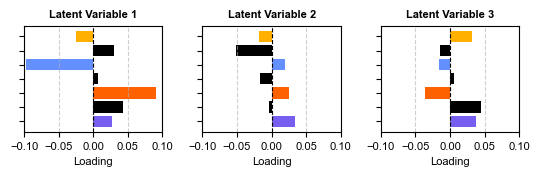

In [16]:
# Plot behavioural group (symptom profile) loadings
import matplotlib.pyplot as plt

ibm_palette = [
    '#785EF0', '#DC267F', '#FE6100','#888888', '#648FFF', '#009E73','#FFB000'
]
label_map = {
    'cognitive' : 'Cognitive',
    'externalizing' : 'Externalising',
    'high_scores' : 'High Psychopathology',
    'internalizing' : 'Internalising',
    'noproblems' : 'No Problems',
    'somaticizing' : 'Somaticising',
    'withdrawnsocialprob' : 'Social Problems'
}
archetype_specific_colors = dict(zip(label_map.keys(), ibm_palette))
# set up plotting
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(5.5,2.2), sharey=True)

# labels from the original Y df, dropping first column
behavioral_labels = membership_aligned.columns[1:]

x_ticks_by_lv = {
    0: [-0.1, -0.05, 0, 0.05, 0.1],
    1: [-0.1, -0.05, 0, 0.05, 0.1],
    2: [-0.1, -0.05, 0, 0.05, 0.1]
}

# Loop through LV1, LV2, and LV3
for i in range(3):
    ax = axes[i]
    
    saliences = pls_gene_test.y_loadings[:, i]
    
    # colors for bars
    bar_colors = [archetype_specific_colors.get(name, 'black') for name in behavioral_labels]
    
    # horizontal bar chart
    ax.barh(behavioral_labels, saliences, color=bar_colors)

    ax.set_xticks(x_ticks_by_lv[i])
    ax.set_xlim(min(x_ticks_by_lv[i]), max(x_ticks_by_lv[i]))
    
    # overwrite labels with cleaned labels
    # pretty_labels = [label_map.get(name, name) for name in behavioral_labels]
    ax.set_yticklabels("", fontsize=8, weight = 'bold')

    
    ax.set_title(f"Latent Variable {i+1}", fontsize=8, weight = 'bold')
    ax.set_xlabel("Loading", fontsize=8)
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
    ax.grid(axis='x', linestyle='--', alpha=0.6)
    ax.tick_params(axis='x', labelsize=8)

# Restore the y-axis label on the first plot
axes[0].set_ylabel("", fontsize=14)

fig.suptitle("", fontsize=8)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# fig.savefig("Behavior_genPLS.png", dpi=600, bbox_inches='tight')

/var/folders/11/vfl4z8m95mn5h2y8rbf8jfm000075w/T/ipykernel_75468/3243704979.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(pretty_labels, fontsize=8, weight = 'bold')
/var/folders/11/vfl4z8m95mn5h2y8rbf8jfm000075w/T/ipykernel_75468/3243704979.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(pretty_labels, fontsize=8, weight = 'bold')
/var/folders/11/vfl4z8m95mn5h2y8rbf8jfm000075w/T/ipykernel_75468/3243704979.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(pretty_labels, fontsize=8, weight = 'bold')


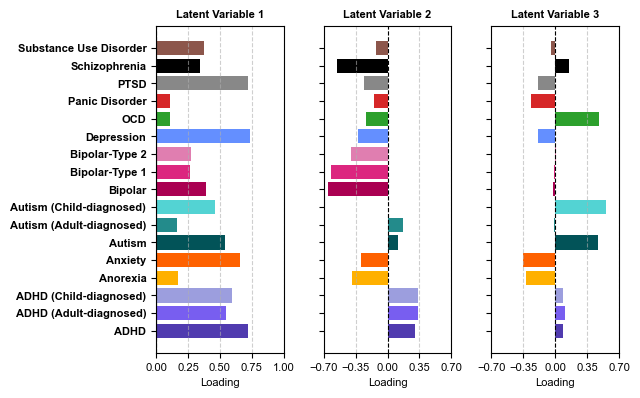

In [ ]:
# Plot gene loadings
gene_palette = [
    "#503BAF", '#785EF0', '#9c9ede', # ADHD colors
    "#FFB000", "#FE6100", # Anorexia, anxiety
    "#025358","#238B8B", "#53D3D3", # Autism colors
    "#AA0052", "#DC267F", "#e07eb0", # Bipolar colors
    "#648FFF", # Depression 
    "#2ca02c", # OCD
    "#d62728", # Panic Disorder
    "#888888", # Personality Disorder
    "#000000", # PTSD
    "#8c564b"# Schizophrenia, SUD

]

label_map = {
    'adhd2022': 'ADHD', 
    'adhd_adult_2022': 'ADHD (Adult-diagnosed)', 
    'adhd_child_2022': 'ADHD (Child-diagnosed)',
    'an2019': 'Anorexia', 
    'anx2024': 'Anxiety', 
    'asd2022': 'Autism',
    'asd_late_2022': 'Autism (Adult-diagnosed)',  
    'asd_early_2022': 'Autism (Child-diagnosed)',
    'bip2024': 'Bipolar', 
    'bip_type1_2021': 'Bipolar-Type 1', 
    'bip_type2_2021': 'Bipolar-Type 2',
    'mdd2025': 'Depression', 
    'ocd2024': 'OCD', 
    'panic2019': 'Panic Disorder', 
    'ptsd2024': 'PTSD', 
    'scz2022': 'Schizophrenia',
    'sud2023': 'Substance Use Disorder'
}

x_ticks_by_lv_gen = {
    0: [0, 0.25,0.5, 0.75, 1],
    1: [-0.7, -0.35, 0, 0.35, 0.7],
    2: [-0.7, -0.35, 0, 0.35, 0.7]
}

archetype_specific_colors = dict(zip(label_map.keys(), gene_palette))
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(6.5, 4.6), sharey=True)

behavioral_labels = list(label_map.keys())
X_numeric = np.array(PGS_h, dtype=float)

# Calculate loadings
x_loadings = np.zeros_like(pls_gene_test.x_weights)
for lv in range(pls_gene_test.x_scores.shape[1]):
    for i in range(X_numeric.shape[1]):
        x_loadings[i, lv] = np.corrcoef(X_numeric[:, i], pls_gene_test.x_scores[:, lv])[0, 1]

# Loop through LV1, LV2, and LV3
for i in range(3):
    ax = axes[i]
    
    saliences = x_loadings[:, i]
    
    # colors for bars
    bar_colors = [archetype_specific_colors.get(name, 'black') for name in behavioral_labels]
    
    # horizontal bar chart
    ax.barh(behavioral_labels, saliences, color=bar_colors)

    ax.set_xticks(x_ticks_by_lv_gen[i])
    ax.set_xlim(min(x_ticks_by_lv_gen[i]), max(x_ticks_by_lv_gen[i]))
    
    # overwrite labels with cleaned labels
    pretty_labels = [label_map.get(name, name) for name in behavioral_labels]
    ax.set_yticklabels(pretty_labels, fontsize=8, weight = 'bold')

    
    ax.set_title(f"Latent Variable {i+1}", fontsize=8, weight = 'bold')
    ax.set_xlabel("Loading", fontsize=8)
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
    ax.grid(axis='x', linestyle='--', alpha=0.6)
    ax.tick_params(axis='x', labelsize=8)

# Restore the y-axis label on the first plot
axes[0].set_ylabel("", fontsize=8)

fig.suptitle("", fontsize=8)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
# fig.savefig("Genes_genPLS.png", dpi=600, bbox_inches='tight')

### Correlation of LV1s across the resting-state functional connectivity (rsFC) and PGR PLS models

In [ ]:
# Load PLS rsFC model
pls_membership_80_1000it = joblib.load('pls_membership_80_1000it.joblib')

print("\nVariance Explained (%):")
print(pls_membership_80_1000it.varexp * 100)

print("\nP-values:")
print(pls_membership_80_1000it.permres.pvals)


Variance Explained (%):
[28.32386514 18.56936876 15.54025318 12.65198809 12.11816298 11.46792309
  1.32843877]

P-values:
[0.000999   0.01198801 0.08691309 0.34665335 0.63436563 0.72327672
 0.5994006 ]


In [20]:
# Correlation of LV1s across the two models

# Take IDs
gene_participant_ids = membership_aligned['src_subject_id'].str.replace('_', '').values

Y_df = pd.read_csv('behavioral_matrix_pooled.csv')
Y_df['src_subject_id'] = Y_df['src_subject_id'].str.replace('_', '')
brain_participant_id = Y_df['src_subject_id'].astype(str).values

# Take intersection of participant IDs in both models
gene_scores_df = pd.DataFrame({
    "ID": gene_participant_ids,
    "LV1_gene": pls_gene_test.y_scores[:, 0],
    "LV1_gene_xscore": pls_gene_test.x_scores[:, 0]
}).set_index("ID")

brain_scores_df = pd.DataFrame({
    "ID": brain_participant_id,
    "LV1_brain": pls_membership_80_1000it.y_scores[:, 0],
    "LV1_brain_xscore": pls_membership_80_1000it.x_scores[:, 0]
}).set_index("ID")

common_ids = gene_scores_df.index.intersection(brain_scores_df.index)

aligned_gene = gene_scores_df.loc[common_ids]
aligned_brain = brain_scores_df.loc[common_ids]

# Compute Pearson correlation of LV1 scores
from scipy.stats import spearmanr
from scipy.stats import pearsonr

r, p = spearmanr(aligned_gene["LV1_gene"], aligned_brain["LV1_brain"])
print(f"Spearman r = {r:.3f}, p = {p:.3e}")


Spearman r = -0.994, p = 0.000e+00


### Post-hoc analysis - GLM

In [24]:
# GLM model with all cors, categorical and continuous confounds
import statsmodels.api as sm

PGS_df = pd.DataFrame(PGS_aligned)
PGS_df['src_subject_id'] = PGS_df['src_subject_id'].str.replace('_', '')
member_df = pd.DataFrame(membership_aligned)
member_df['src_subject_id'] = member_df['src_subject_id'].str.replace('_', '')

demo_merged = pd.read_csv('demo_merged.csv')
merged_df = pd.merge(PGS_df, member_df, on='src_subject_id', how='inner')
final_df = pd.merge(merged_df, demo_merged, on='src_subject_id', how='left')


cont_cols = ['interview_age', 'rsfmri_meanmotion']
cat_cols = ['sex', 'site_id_l']
confound_cols = cont_cols + cat_cols
# all confounds: 'sex', 'interview_age', 'rsfmri_meanmotion', 'rsfmri_meanrot', 'rsfmri_meantrans', 'site_id_l'

confounds_glm = final_df[confound_cols].copy()

x_scores = pls_gene_test.x_scores
y_scores = pls_gene_test.y_scores
x_scores_lv1 = x_scores[:, 0]
y_scores_lv1 = y_scores[:, 0]

model_data = confounds_glm
model_data['x_score_lv1'] = x_scores_lv1
model_data['y_score_lv1'] = y_scores_lv1

# check for NaNs
print(f"Original shape (subjects): {model_data.shape[0]}")
print(f"Missing values:\n{model_data.isnull().sum()}")

# Drop any row that has a NaN in ANY column
model_data_clean = model_data.dropna().copy()
print(f"\nNew number of subjects after dropping NaNs: {model_data_clean.shape[0]}")

# scale only continuous confounds
scaler = StandardScaler()
model_data_clean[cont_cols] = scaler.fit_transform(model_data_clean[cont_cols])

# dummy code only categorical confounds
model_data_final = pd.get_dummies(
    model_data_clean, 
    columns=cat_cols, 
    drop_first=True,# remove first dummy column to avoid multicollinearity
    dtype=int 
)

# Get the Y variable (from the clean DataFrame)
y_glm2_lv1 = model_data_final['y_score_lv1']

X_glm2 = model_data_final.drop(columns='y_score_lv1')

# Add the intercept
X_glm2_with_const = sm.add_constant(X_glm2)

# Get the final list of all predictor names for the summary
X_glm2_colnames = X_glm2_with_const.columns.tolist()


results2_lv1 = sm.GLM(
    y_glm2_lv1,
    X_glm2_with_const,
    family=sm.families.Gaussian()
).fit(cov_type='HC3')

print(results2_lv1.summary(xname=X_glm2_colnames))

export_df_LV1 = pd.DataFrame({
    "coef": results2_lv1.params,
    "std_err": results2_lv1.bse,
    "z_value": results2_lv1.tvalues,  # tvalues works for Gaussian GLM
    "p_value": results2_lv1.pvalues,
    "CI_lower": results2_lv1.conf_int()[0],
    "CI_upper": results2_lv1.conf_int()[1]
})

# Reset index to have predictor names as a column
export_df_LV1 = export_df_LV1.reset_index().rename(columns={"index": "predictor"})

# Export to CSV
export_df_LV1.to_csv("Gene_GLM_results_LV1.csv", index=False)

Original shape (subjects): 5672
Missing values:
interview_age        151
rsfmri_meanmotion    237
sex                  151
site_id_l            151
x_score_lv1            0
y_score_lv1            0
dtype: int64

New number of subjects after dropping NaNs: 5435
                 Generalized Linear Model Regression Results                  
Dep. Variable:            y_score_lv1   No. Observations:                 5435
Model:                            GLM   Df Residuals:                     5409
Model Family:                Gaussian   Df Model:                           25
Link Function:               Identity   Scale:                          1.4971
Method:                          IRLS   Log-Likelihood:                -8795.4
Date:                Tue, 21 Apr 2026   Deviance:                       8097.7
Time:                        19:14:22   Pearson chi2:                 8.10e+03
No. Iterations:                     3   Pseudo R-squ. (CS):            0.03561
Covariance Type:            

In [25]:
# GLM model with all cors, categorical and continuous confounds
import statsmodels.api as sm

PGS_df = pd.DataFrame(PGS_aligned)
PGS_df['src_subject_id'] = PGS_df['src_subject_id'].str.replace('_', '')
member_df = pd.DataFrame(membership_aligned)
member_df['src_subject_id'] = member_df['src_subject_id'].str.replace('_', '')

demo_merged = pd.read_csv('demo_merged.csv')
merged_df = pd.merge(PGS_df, member_df, on='src_subject_id', how='inner')
final_df = pd.merge(merged_df, demo_merged, on='src_subject_id', how='left')


cont_cols = ['interview_age', 'rsfmri_meanmotion']
cat_cols = ['sex', 'site_id_l']
confound_cols = cont_cols + cat_cols
# all confounds: 'sex', 'interview_age', 'rsfmri_meanmotion', 'rsfmri_meanrot', 'rsfmri_meantrans', 'site_id_l'

confounds_glm = final_df[confound_cols].copy()

x_scores = pls_gene_test.x_scores
y_scores = pls_gene_test.y_scores
x_scores_lv2 = x_scores[:, 1]
y_scores_lv2 = y_scores[:, 1]

model_data = confounds_glm
model_data['x_score_lv2'] = x_scores_lv2
model_data['y_score_lv2'] = y_scores_lv2

# check for NaNs
print(f"Original shape (subjects): {model_data.shape[0]}")
print(f"Missing values:\n{model_data.isnull().sum()}")

# Drop any row that has a NaN in ANY column
model_data_clean = model_data.dropna().copy()
print(f"\nNew number of subjects after dropping NaNs: {model_data_clean.shape[0]}")

# scale only continuous confounds
scaler = StandardScaler()
model_data_clean[cont_cols] = scaler.fit_transform(model_data_clean[cont_cols])

# dummy code only categorical confounds
model_data_final = pd.get_dummies(
    model_data_clean, 
    columns=cat_cols, 
    drop_first=True,# remove first dummy column to avoid multicollinearity
    dtype=int 
)

# Get the Y variable (from the clean DataFrame)
y_glm2_lv2 = model_data_final['y_score_lv2']

X_glm2 = model_data_final.drop(columns='y_score_lv2')

# Add the intercept
X_glm2_with_const = sm.add_constant(X_glm2)

# Get the final list of all predictor names for the summary
X_glm2_colnames = X_glm2_with_const.columns.tolist()


results2_lv2 = sm.GLM(
    y_glm2_lv2,
    X_glm2_with_const,
    family=sm.families.Gaussian()
).fit(cov_type='HC3')

print(results2_lv2.summary(xname=X_glm2_colnames))

export_df_LV2 = pd.DataFrame({
    "coef": results2_lv2.params,
    "std_err": results2_lv2.bse,
    "z_value": results2_lv2.tvalues,  # tvalues works for Gaussian GLM
    "p_value": results2_lv2.pvalues,
    "CI_lower": results2_lv2.conf_int()[0],
    "CI_upper": results2_lv2.conf_int()[1]
})

# Reset index to have predictor names as a column
export_df_LV2 = export_df_LV2.reset_index().rename(columns={"index": "predictor"})

# Export to CSV
export_df_LV2.to_csv("Gene_GLM_results_LV2.csv", index=False)

Original shape (subjects): 5672
Missing values:
interview_age        151
rsfmri_meanmotion    237
sex                  151
site_id_l            151
x_score_lv2            0
y_score_lv2            0
dtype: int64

New number of subjects after dropping NaNs: 5435
                 Generalized Linear Model Regression Results                  
Dep. Variable:            y_score_lv2   No. Observations:                 5435
Model:                            GLM   Df Residuals:                     5409
Model Family:                Gaussian   Df Model:                           25
Link Function:               Identity   Scale:                          1.1125
Method:                          IRLS   Log-Likelihood:                -7988.6
Date:                Tue, 21 Apr 2026   Deviance:                       6017.4
Time:                        19:14:31   Pearson chi2:                 6.02e+03
No. Iterations:                     3   Pseudo R-squ. (CS):            0.01559
Covariance Type:            

In [23]:
# GLM model with all cors, categorical and continuous confounds
import statsmodels.api as sm

PGS_df = pd.DataFrame(PGS_aligned)
PGS_df['src_subject_id'] = PGS_df['src_subject_id'].str.replace('_', '')
member_df = pd.DataFrame(membership_aligned)
member_df['src_subject_id'] = member_df['src_subject_id'].str.replace('_', '')

demo_merged = pd.read_csv('demo_merged.csv')
merged_df = pd.merge(PGS_df, member_df, on='src_subject_id', how='inner')
final_df = pd.merge(merged_df, demo_merged, on='src_subject_id', how='left')


cont_cols = ['interview_age', 'rsfmri_meanmotion']
cat_cols = ['sex', 'site_id_l']
confound_cols = cont_cols + cat_cols
# all confounds: 'sex', 'interview_age', 'rsfmri_meanmotion', 'rsfmri_meanrot', 'rsfmri_meantrans', 'site_id_l'

confounds_glm = final_df[confound_cols].copy()

x_scores = pls_gene_test.x_scores
y_scores = pls_gene_test.y_scores
x_scores_lv3 = x_scores[:, 2]
y_scores_lv3 = y_scores[:, 2]

model_data = confounds_glm
model_data['x_score_lv3'] = x_scores_lv3
model_data['y_score_lv3'] = y_scores_lv3

# check for NaNs
print(f"Original shape (subjects): {model_data.shape[0]}")
print(f"Missing values:\n{model_data.isnull().sum()}")

# Drop any row that has a NaN in ANY column
model_data_clean = model_data.dropna().copy()
print(f"\nNew number of subjects after dropping NaNs: {model_data_clean.shape[0]}")

# scale only continuous confounds
scaler = StandardScaler()
model_data_clean[cont_cols] = scaler.fit_transform(model_data_clean[cont_cols])

# dummy code only categorical confounds
model_data_final = pd.get_dummies(
    model_data_clean, 
    columns=cat_cols, 
    drop_first=True,# remove first dummy column to avoid multicollinearity
    dtype=int 
)

# Get the Y variable (from the clean DataFrame)
y_glm3_lv3 = model_data_final['y_score_lv3']

X_glm3 = model_data_final.drop(columns='y_score_lv3')

# Add the intercept
X_glm3_with_const = sm.add_constant(X_glm3)

# Get the final list of all predictor names for the summary
X_glm3_colnames = X_glm3_with_const.columns.tolist()


results3_lv3 = sm.GLM(
    y_glm3_lv3,
    X_glm3_with_const,
    family=sm.families.Gaussian()
).fit(cov_type='HC3')

print(results3_lv3.summary(xname=X_glm3_colnames))

export_df_LV3 = pd.DataFrame({
    "coef": results3_lv3.params,
    "std_err": results3_lv3.bse,
    "z_value": results3_lv3.tvalues,  # tvalues works for Gaussian GLM
    "p_value": results3_lv3.pvalues,
    "CI_lower": results3_lv3.conf_int()[0],
    "CI_upper": results3_lv3.conf_int()[1]
})

# Reset index to have predictor names as a column
export_df_LV3 = export_df_LV3.reset_index().rename(columns={"index": "predictor"})

# Export to CSV
export_df_LV3.to_csv("Gene_GLM_results_LV3.csv", index=False)

Original shape (subjects): 5672
Missing values:
interview_age        151
rsfmri_meanmotion    237
sex                  151
site_id_l            151
x_score_lv3            0
y_score_lv3            0
dtype: int64

New number of subjects after dropping NaNs: 5435
                 Generalized Linear Model Regression Results                  
Dep. Variable:            y_score_lv3   No. Observations:                 5435
Model:                            GLM   Df Residuals:                     5409
Model Family:                Gaussian   Df Model:                           25
Link Function:               Identity   Scale:                          1.0767
Method:                          IRLS   Log-Likelihood:                -7899.8
Date:                Tue, 21 Apr 2026   Deviance:                       5824.0
Time:                        19:13:38   Pearson chi2:                 5.82e+03
No. Iterations:                     3   Pseudo R-squ. (CS):            0.01062
Covariance Type:            

In [28]:
# Plot of PLS loadings on map weights

# Custom colors
from matplotlib.colors import LinearSegmentedColormap
colors = ["#025358","#238B8B", "#FFFFFFFF","#e07eb0", "#CE0063"]
custom_cmap = LinearSegmentedColormap.from_list("mycmap", colors)

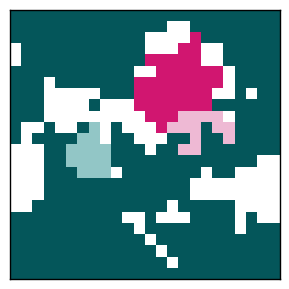

In [30]:
# Plot of SOM colored by the LV salience - cycle through LV1, LV2, LV3

import matplotlib as mpl

# Island BMU locations
import seaborn as sns
import json
from scipy.interpolate import griddata
with open("final_islands_report_split.json", "r") as f:
    island_bmus = json.load(f)

# impose order of PLS columns
ordered_names = [
    'simulated_cognitive', 
    'simulated_externalizing', 
    'simulated_high_scores', 
    'simulated_internalizing', 
    'simulated_noproblems', 
    'simulated_somaticizing', 
    'simulated_withdrawnsocialprob'
]


# Extract loadings
lv_idx = 0 # LV1=0, LV2=1, LV3=2
saliences = pls_gene_test.y_loadings[:, lv_idx]

# grid for plotting (to be filled in with y weights)
som_width, som_height = 24, 24
som_matrix = np.zeros((som_height, som_width))
data_mask = np.zeros((som_height, som_width), dtype=bool) # False = No Data


# Mapping on SOM grid
for i, col in enumerate(ordered_names):
    json_key = col
    weight = saliences[i]

    if json_key in island_bmus:
        for cluster in island_bmus[json_key]:
            for node in cluster:
                r,c = node[0], node[1]
                if r<som_height and c<som_width:
                    som_matrix[r, c] = weight
                    data_mask[r, c] = True


all_saliences = pls_gene_test.y_loadings[:, :3]
global_vmax = np.max(np.abs(all_saliences))

norm = mpl.colors.TwoSlopeNorm(
    vmin=-0.1,
    vcenter=0,
    vmax=0.1
)

# Plot SOM colored by loading

fig, ax =plt.subplots(figsize=(3.5, 3.5))

sns.heatmap(
    som_matrix,
    cmap=custom_cmap,
    norm=norm,
    #vmin=-brain_max,
    #vmax=brain_max,
    square=True,
    mask=~data_mask,  # Mask where there is no data
    #cbar_kws={'label': 'Behavioral Salience (LV1)'},
    cbar=False,
    ax=ax,
    xticklabels=False,
    yticklabels=False
)

# Add border
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_linewidth(1)
    
plt.show()
fig.set_size_inches(3.5, 3.5)
# fig.savefig("LV1_SOM_gene.jpeg", dpi=600, bbox_inches='tight')   

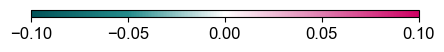

In [ ]:
# Generate color bar

from matplotlib.colorbar import ColorbarBase

fig_cbar, ax_cbar = plt.subplots(figsize=(5, 0.1))

ColorbarBase(
    ax_cbar,
    cmap=custom_cmap,
    norm=norm,
    orientation='horizontal',
    ticks=[-0.1, -0.05, 0, 0.05, 0.1]
)

ax_cbar.tick_params(labelsize=12)
fig_cbar.savefig("Behavior_gene_sal_cbar.png", dpi=600, bbox_inches='tight')
